### Import Necessary Packages and Libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import make_scorer, mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score

import joblib
import optuna

In [2]:
# Read in csv
df = pd.read_csv('~/Desktop/ADA/ADA-final-project/data_ingestion/preprocessed_award_data.csv')
print(df.shape)
df_embed = pd.read_csv('contract_embeddings.csv')

(247241, 36)


In [3]:
df = df.merge(df_embed, on = 'generated_internal_id')
print(df.shape)

(247241, 420)


# Predict Total Value of Award (before looking at any modification / follow on information)

In [4]:
# Define columns for Machine Learning Processing
categorical_predictors = ['Awarding Agency' , 'Awarding Sub Agency', 'Funding Agency',
                         'Funding Sub Agency', 'Place of Performance Country Code', 'Place of Performance State Code',
                         'is_democrat', 'naics_code', 'start_year', 'award_not_fund_agency', 'award_not_fund_sub_agency'] # leave out psc_code (~ 900 values)
emb_cols = [col for col in df_embed if col != 'generated_internal_id']
continuous_predictors = ['market_share'] + emb_cols
target = 'Award Amount'
metadata = ['internal_id', 'Award ID_x', 'generated_internal_id', 'Recipient Name', 'recipient_id']

In [18]:
df = df[categorical_predictors + continuous_predictors + [target]]
df = df.dropna() # Only drops a few thousand records - insignificant comparatively

print(f"Original shape: {df.shape}")
df = df[df[target] > 0].copy()
print(f"Shape after removing zeros: {df.shape}")

Original shape: (242266, 397)
Shape after removing zeros: (238548, 397)


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 238548 entries, 0 to 247240
Columns: 397 entries, Awarding Agency to Award Amount
dtypes: bool(2), float64(388), int64(1), object(6)
memory usage: 721.2+ MB


## Create Log Transformations (including target)

In [20]:
# Log transform the target to handle skewness
# Use log1p (log(1+x)) to handle any potential 0 or small values safely
df['target_log'] = np.log1p(df[target])

# Update X and y
X = df[categorical_predictors + continuous_predictors]
y_log = df['target_log']

# Split data
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Simplified Preprocessor for Boosting Models
# XGBoost handles sparse data well; RobustScaler handles outliers in market_share/embeddings
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), continuous_predictors),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_predictors)
    ])

# Pre-process the training data for Optuna (to avoid repeating it every trial)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

## Bayesian Optimization with Optuna (XGBoost)

In [21]:
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_jobs': -1,
        'random_state': 42,
        'objective': 'reg:squarederror'
    }
    
    model = XGBRegressor(**param)
    
    # Using 3-fold CV for speed during optimization
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    # We optimize for Negative Mean Squared Error on the LOG scale
    score = cross_val_score(model, X_train_transformed, y_train_log, cv=kf, scoring='neg_mean_squared_error')
    
    return score.mean()

# Run the optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25) # Increase n_trials for better results

print(f"Best trial: {study.best_trial.params}")

[I 2026-05-18 18:02:00,912] A new study created in memory with name: no-name-9b37dd3b-d8bb-4d72-b48c-eb7375c338c3
[I 2026-05-18 18:03:22,616] Trial 0 finished with value: -2.5455604515059496 and parameters: {'n_estimators': 632, 'max_depth': 4, 'learning_rate': 0.12572119966578219, 'subsample': 0.7581573338878725, 'colsample_bytree': 0.7180961120834555, 'reg_alpha': 7.029716820340474e-06, 'reg_lambda': 0.00016051902964028269}. Best is trial 0 with value: -2.5455604515059496.
[I 2026-05-18 18:04:39,419] Trial 1 finished with value: -2.626524883827757 and parameters: {'n_estimators': 468, 'max_depth': 6, 'learning_rate': 0.029463793031741323, 'subsample': 0.9616489463755888, 'colsample_bytree': 0.9687819923983527, 'reg_alpha': 0.008447770781727166, 'reg_lambda': 0.6303094952890066}. Best is trial 0 with value: -2.5455604515059496.
[I 2026-05-18 18:06:35,090] Trial 2 finished with value: -2.439326918788695 and parameters: {'n_estimators': 720, 'max_depth': 6, 'learning_rate': 0.0957767367

Best trial: {'n_estimators': 893, 'max_depth': 9, 'learning_rate': 0.07040080540424554, 'subsample': 0.8624517259335512, 'colsample_bytree': 0.7819670571788703, 'reg_alpha': 0.08532789899745381, 'reg_lambda': 1.891329486012898e-06}


# Final Model Training and Evaluation

# Save Models and Metrics to Disk

In [22]:
version = "v3"

# IMPORTANT!!!!
## Ensure Proper Version Number above is specified before running!

In [23]:
# Train the best model found by Optuna
best_model = XGBRegressor(**study.best_params)
best_model.fit(X_train_transformed, y_train_log)

# Create the full pipeline (for easy saving/loading)
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', best_model)
])

# Predict and Inverse Transform to original scale
y_pred_log = final_pipeline.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

# Calculate Metrics
mape = mean_absolute_percentage_error(y_test_actual, y_pred)
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print(f"Final MAPE: {mape:.4f}")
print(f"Final MAE Score: {mae:.4f}")
print(f"Final RMSE Score: {rmse:.4f}")
print(f"Final R2 Score: {r2:.4f}")

# Save Model and Append to CSV (matching your format)
filename = f"models/regression/xgboost_bayesian_reg_{version}.joblib"
joblib.dump(final_pipeline, filename)

results_list = [{
    "model_name": f"XGBoost_Bayesian_reg_{version}",
    "model_location": filename,
    "MAPE": round(mape, 4),
    "MAE": round(mae, 2),
    "RMSE": round(rmse, 2),
    "R2_Score": round(r2, 4)
}]

# Create/Update the summary CSV
df_metrics = pd.DataFrame(results_list)

try:
    df_metrics_old = pd.read_csv("amount_regression_model_evaluation_metrics.csv")
    df_metrics = pd.concat([df_metrics_old, df_metrics], axis=0).drop_duplicates(subset=['model_name'])
except FileNotFoundError:
    pass

df_metrics.to_csv("amount_regression_model_evaluation_metrics.csv", index=False)

print("Optimized model saved and metrics CSV updated successfully.")
display(df_metrics)

Final MAPE: 1095.7206
Final MAE Score: 803781.3850
Final RMSE Score: 6910232.1632
Final R2 Score: 0.0561
Optimized model saved and metrics CSV updated successfully.


,model_name,model_location,MAPE,MAE,RMSE,R2_Score
0,Elastic Net_reg_v1,models/regression/elastic_net_model_regression...,6.179195e+19,1285601.83,6293819.84,0.0204
1,Decision Tree_reg_v1,models/regression/decision_tree_model_regressi...,7.306905e+19,1361773.57,10273197.74,-1.6098
2,XGBoost_Bayesian_reg_v2,models/regression/xgboost_bayesian_reg_v2.joblib,8.863642e+18,754544.63,6203614.81,0.0483
0,XGBoost_Bayesian_reg_v3,models/regression/xgboost_bayesian_reg_v3.joblib,1.095721e+03,803781.38,6910232.16,0.0561


## XGBoost Feature Importance

Top 20 Most Important Features:


,Feature,Importance
0,Awarding Sub Agency_Department of State,0.118300
1,naics_code_541511.0,0.032316
2,Funding Sub Agency_Department of State,0.031667
3,Awarding Sub Agency_Defense Information System...,0.028845
4,naics_code_541512.0,0.024680
5,Funding Sub Agency_Federal Prison System / Bur...,0.023834
6,Awarding Agency_Department of State,0.023382
7,Funding Sub Agency_Federal Aviation Administra...,0.018808
8,Awarding Sub Agency_Federal Prison System / Bu...,0.018803
9,Funding Sub Agency_Rural Housing Service,0.018631


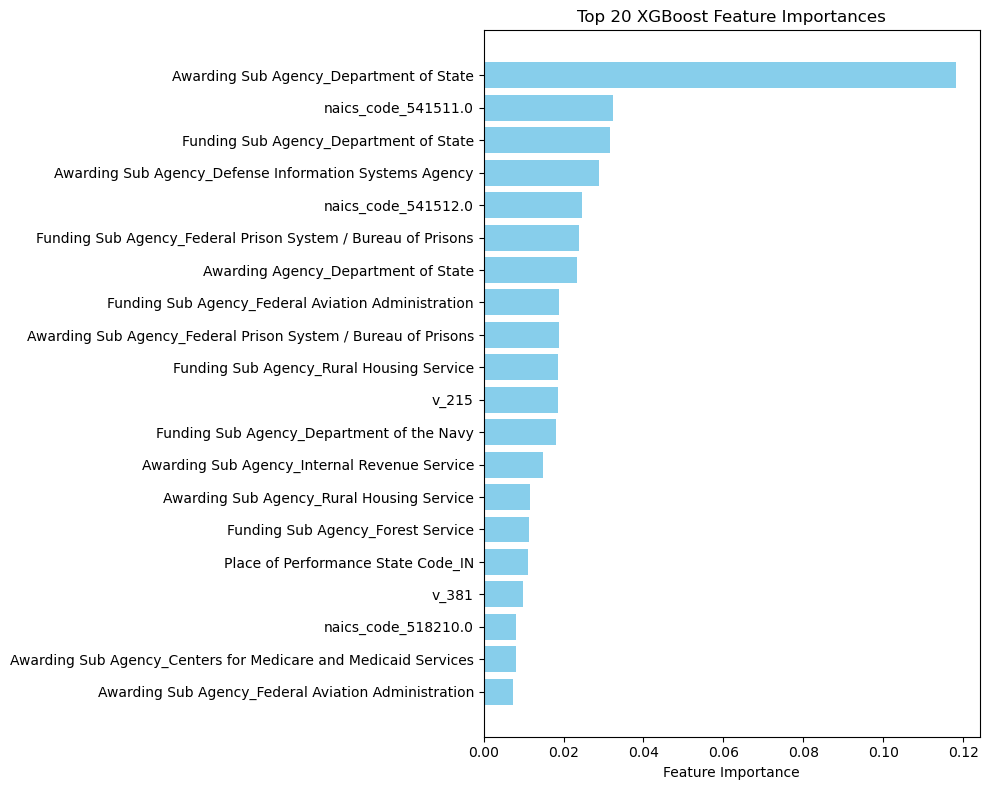

In [41]:
# Get the feature names from the fitted preprocessor
feature_names = preprocessor.get_feature_names_out()

# Clean up the names to remove the 'num__' and 'cat__' prefixes if desired
feature_names_clean = [name.split('__')[-1] for name in feature_names]

# Get feature importances from the trained XGBoost model
importances = best_model.feature_importances_

# Create a DataFrame to view and sort them
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_clean,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Display the top 20 features
print("Top 20 Most Important Features:")
display(feature_importance_df.head(20))

# Plot the top 20 features for visualization
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'].head(20)[::-1], 
         feature_importance_df['Importance'].head(20)[::-1], 
         color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Top 20 XGBoost Feature Importances')
plt.tight_layout()
plt.savefig('xgb_feature_importance_regression.png')

In [44]:
y_pred

array([1.52884180e+03, 1.21812805e+05, 2.25871812e+05, ...,
       1.10322070e+07, 3.11522539e+04, 7.49864219e+04],
      shape=(47710,), dtype=float32)

### How many Contracts Valued at Zero?

<Axes: >

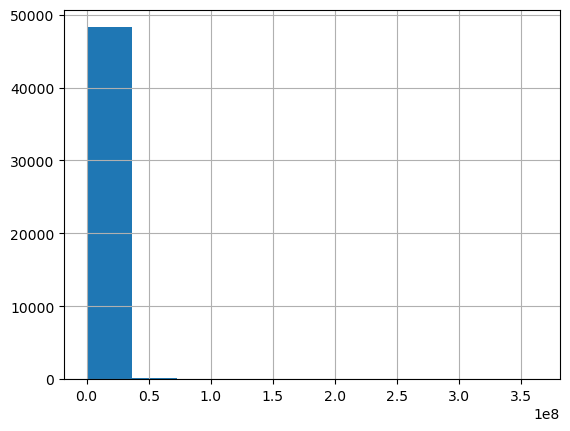

In [17]:
y_test_actual.hist()